In [11]:
%reset -f

In [12]:
from simtk.openmm.app import *
from simtk.openmm import *
from simtk.openmm.app import PDBFile
from pdbfixer import PDBFixer
import numpy as np
import mdtraj as md
from simtk.openmm import CustomBondForce
from simtk.unit import *
from simtk import unit
from sys import stdout
import random as rd
import matplotlib.pylab as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [13]:
#os.chdir('/home/indio/openmm-calpha/ezequiel/1cyc')

In [14]:
forcefield = ForceField("cg.xml")
file="protein.pdb"
file2="ca_onlyCerrado.pdb"
inpdb = "single_frame.pdb"
outcleaned = file
outca = file2
estructura_cerrada = "ca_onlyCerrado.pdb"
estructura_abierta = 'ca_onlyAbierto.pdb'

In [15]:
fixer = PDBFixer(inpdb)
fixer.removeHeterogens(keepWater=False)
PDBFile.writeFile(fixer.topology, fixer.positions, open(outcleaned, 'w'))

pdb = md.load(outcleaned)
keep_list = []
for atom in pdb.topology.atoms:
    if atom.name == "CA":
        keep_list.append(atom.index)
chosen = pdb.atom_slice(keep_list)
chosen.save(outca)

In [16]:
##############contactos: se puede usar el siguiente protocolo o 
##############armar una contact_list (i j) con los atomos interaccionando
##############y otro parameter2_list (distancia)cleaned con la distancia entre 
##############los atomos de contact_list.

In [17]:

'''
def convertCPPTRAJcontactDF (inputFname,outputFname,offset):
    df=pd.read_table(inputFname,sep=r'\s+')
    df = df[['TotalFrac','#Res1','Contacts','#Res2']]
    offsetCondition = df['#Res2'] < df['#Res1']+offset
    df = df.drop(df[offsetCondition].index)
    df.to_csv(outputFname,sep=' ',header=False,index=False)
    return df

fname ='res_contacts.dat'
contactFile='contactos.contacts'
resOffset = 2 #distancia mínima en secuencia lineal para considerar contacto
convertCPPTRAJcontactDF(fname,contactFile,resOffset)'''

"\ndef convertCPPTRAJcontactDF (inputFname,outputFname,offset):\n    df=pd.read_table(inputFname,sep=r'\\s+')\n    df = df[['TotalFrac','#Res1','Contacts','#Res2']]\n    offsetCondition = df['#Res2'] < df['#Res1']+offset\n    df = df.drop(df[offsetCondition].index)\n    df.to_csv(outputFname,sep=' ',header=False,index=False)\n    return df\n\nfname ='res_contacts.dat'\ncontactFile='contactos.contacts'\nresOffset = 2 #distancia mínima en secuencia lineal para considerar contacto\nconvertCPPTRAJcontactDF(fname,contactFile,resOffset)"

In [18]:
def generar_lista_contactos(contactFile):

    df = pd.read_csv(contactFile, sep=" ", skiprows=1, header=None)
    print(df)
    df.columns=['0','i','0','j']
    df.astype('int32')
    
    df=df[['i','j']]
    a=list(df['i']-1)
    b=list(df['j']-1)

    return list(zip(a, b))

def generar_lista_parametros(contact_list, outca):
    parameter_list = []
    coord = md.load_pdb(outca)
    for i in range(len(contact_list)):
        h1 = np.array([[contact_list[i][0], contact_list[i][1]]])
        x = md.compute_distances(coord, h1)[0][0]
        parameter_list.append(x)
    return parameter_list

def plotear_contactos(contact_list, parameter_list):
    np.shape(contact_list)
    x1 = [i[0] for i in contact_list]
    y1 = [i[1] for i in contact_list]
    z1 = [i for i in parameter_list]

    x2 = [i[0] for i in contact_list]
    y2 = [i[1] for i in contact_list]
    z2 = [i for i in parameter_list]
    print(min(z2))
    plt.scatter(x1,y1, c= z1)
    plt.scatter(x2,y2, c = z2, alpha=0.2)
    plt.colorbar()

     0    1  2    3
0    1  929  1  932
1    1  274  1  277
2    1   65  1   71
3    1  360  1  930
4    1   69  1   72
..  ..  ... ..  ...
224  1  299  1  310
225  1  584  1  689
226  1  193  1  849
227  1  590  1  595
228  1  594  1  597

[229 rows x 4 columns]
0.5015181


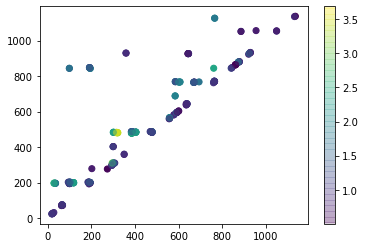

In [19]:
lista_contactos_abierto = generar_lista_contactos('contactos1.5_abierto.dat')

lista_parametros_abierto = generar_lista_parametros(lista_contactos_abierto, estructura_abierta)

plotear_contactos(lista_contactos_abierto, lista_parametros_abierto)

      0     1  2     3
0     1     1  1     3
1     1     2  1     3
2     1     2  1     4
3     1     3  1     4
4     1     3  1     5
...  ..   ... ..   ...
5036  1   724  1   727
5037  1   630  1   727
5038  1   450  1   454
5039  1   603  1   606
5040  1  1133  1  1136

[5041 rows x 4 columns]
0.28790012


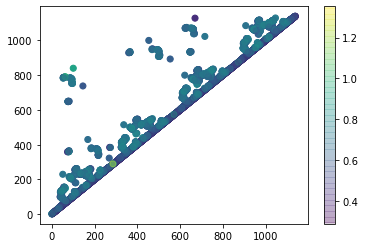

In [20]:
lista_contactos_en_comun= generar_lista_contactos('contactos_en_comun03_openmm.dat') 
lista_parametros_en_comun = generar_lista_parametros(lista_contactos_en_comun, estructura_cerrada)

plotear_contactos(lista_contactos_en_comun, lista_parametros_en_comun)

In [21]:
'''import pandas as pd
import mdtraj as md
import os


contact_list = []
parameter_list = []
parameter2_list= []
extras_list=[]
# read text file into pandas DataFrame
df = pd.read_csv(contactFile, sep=" ", header=None)

df.columns=['0','i','0','j']
df.astype('int32')
df=df[['i','j']]
a=list(df['i']-1)
b=list(df['j']-1)

contact_list2 = list(zip(a, b))
coord = md.load_pdb(outca)

parameter2_list2 = []
for i in range(len(contact_list2)):
#     print('a')
    h1 = np.array([[contact_list2[i][0], contact_list2[i][1]]])
#     print(h1)
    x = md.compute_distances(coord, h1)[0][0]
    parameter2_list2.append(x)
np.shape(contact_list)
# parameter2_list
# contact_list
x1 = [i[0] for i in contact_list]
y1 = [i[1] for i in contact_list]
z1 = [i for i in parameter2_list]

x2 = [i[0] for i in contact_list2]
y2 = [i[1] for i in contact_list2]
z2 = [i for i in parameter2_list2]
print(min(z2))
plt.scatter(x1,y1, c= z1)
plt.scatter(x2,y2, c = z2, alpha=0.2)
plt.colorbar()'''


'import pandas as pd\nimport mdtraj as md\nimport os\n\n\ncontact_list = []\nparameter_list = []\nparameter2_list= []\nextras_list=[]\n# read text file into pandas DataFrame\ndf = pd.read_csv(contactFile, sep=" ", header=None)\n\ndf.columns=[\'0\',\'i\',\'0\',\'j\']\ndf.astype(\'int32\')\ndf=df[[\'i\',\'j\']]\na=list(df[\'i\']-1)\nb=list(df[\'j\']-1)\n\ncontact_list2 = list(zip(a, b))\ncoord = md.load_pdb(outca)\n\nparameter2_list2 = []\nfor i in range(len(contact_list2)):\n#     print(\'a\')\n    h1 = np.array([[contact_list2[i][0], contact_list2[i][1]]])\n#     print(h1)\n    x = md.compute_distances(coord, h1)[0][0]\n    parameter2_list2.append(x)\nnp.shape(contact_list)\n# parameter2_list\n# contact_list\nx1 = [i[0] for i in contact_list]\ny1 = [i[1] for i in contact_list]\nz1 = [i for i in parameter2_list]\n\nx2 = [i[0] for i in contact_list2]\ny2 = [i[1] for i in contact_list2]\nz2 = [i for i in parameter2_list2]\nprint(min(z2))\nplt.scatter(x1,y1, c= z1)\nplt.scatter(x2,y2, c = 

In [22]:
##################Forcefield terms

In [23]:
'''from simtk.openmm import HarmonicBondForce

def ca_bonds(system, enlaces, k_con):
    con=HarmonicBondForce()
    n=system.getNumParticles()
    for i in range(n-1):
        con.addBond(i,i+1,float(enlaces[0][i]),k_con)
    return con'''

'from simtk.openmm import HarmonicBondForce\n\ndef ca_bonds(system, enlaces, k_con):\n    con=HarmonicBondForce()\n    n=system.getNumParticles()\n    for i in range(n-1):\n        con.addBond(i,i+1,float(enlaces[0][i]),k_con)\n    return con'

In [24]:
from simtk.openmm import HarmonicBondForce

def ca_bonds(system, enlaces, k_con,chainRanges):
    con=HarmonicBondForce()
    nBond = 0
    for chRange in chainRanges:
        first,last= chRange
        for i in range(first,last-1):
            con.addBond(i,i+1,float(enlaces[0][nBond]),k_con)
            nBond+=1
    return con

In [25]:
'''from simtk.openmm import HarmonicAngleForce

def angle_term(system, angulos, k_ang):
    ang=HarmonicAngleForce()
    n=system.getNumParticles()
    for i in range(n-2):
        ang.addAngle(i,i+1,i+2,float(angulos[0][i]),k_ang)
    return ang'''

'from simtk.openmm import HarmonicAngleForce\n\ndef angle_term(system, angulos, k_ang):\n    ang=HarmonicAngleForce()\n    n=system.getNumParticles()\n    for i in range(n-2):\n        ang.addAngle(i,i+1,i+2,float(angulos[0][i]),k_ang)\n    return ang'

In [26]:
from simtk.openmm import HarmonicAngleForce

def angle_term(system, angulos, k_ang,chainRanges):
    ang=HarmonicAngleForce()
    nAng = 0
    for chRange in chainRanges:
        first,last= chRange
        for i in range(first,last-2):
            ang.addAngle(i,i+1,i+2,float(angulos[0][nAng]),k_ang)
            nAng+=1
    return ang

In [27]:
'''from simtk.openmm import CustomTorsionForce

def dihedral_term(system, dihedrals, k_dih):
    k_dih=1*(kilojoule_per_mole/radian)
    dih=CustomTorsionForce("k_dih*(1-cos(theta-theta0))+0.5*k_dih*(1-cos(3*(theta-theta0)))")   
    dih.addPerTorsionParameter("k_dih")
    dih.addPerTorsionParameter("theta0")
    n=system.getNumParticles()
    for i in range(n-3):
        dih.addTorsion(i,i+1,i+2,i+3, [k_dih, dihedrals[0][i]])

    return dih'''

'from simtk.openmm import CustomTorsionForce\n\ndef dihedral_term(system, dihedrals, k_dih):\n    k_dih=1*(kilojoule_per_mole/radian)\n    dih=CustomTorsionForce("k_dih*(1-cos(theta-theta0))+0.5*k_dih*(1-cos(3*(theta-theta0)))")   \n    dih.addPerTorsionParameter("k_dih")\n    dih.addPerTorsionParameter("theta0")\n    n=system.getNumParticles()\n    for i in range(n-3):\n        dih.addTorsion(i,i+1,i+2,i+3, [k_dih, dihedrals[0][i]])\n\n    return dih'

In [28]:
from simtk.openmm import CustomTorsionForce

def dihedral_term(system, dihedrals, k_dih,chainRanges):
    k_dih=1*(kilojoule_per_mole/radian)
    dih=CustomTorsionForce("k_dih*(1-cos(theta-theta0))+0.5*k_dih*(1-cos(3*(theta-theta0)))")   
    dih.addPerTorsionParameter("k_dih")
    dih.addPerTorsionParameter("theta0")
    nTor = 0
    for chRange in chainRanges:
        first,last= chRange
        for i in range(first,last-3):
            dih.addTorsion(i,i+1,i+2,i+3, [k_dih, dihedrals[0][nTor]])
            nTor+=1

    return dih

In [29]:
from simtk.openmm import CustomBondForce

def structure_based_term2(contact_list, parameter2_list, ksb):
    
    structure_based = CustomBondForce(f"{ksb}*((5*((r_ijN/r)^(12))) - (6*((r_ijN/r)^(10))))")
    structure_based.addPerBondParameter("ksb")
    structure_based.addPerBondParameter("r_ijN")
    
    for contact, parameters in zip(contact_list, parameter2_list):
        structure_based.addBond(*contact, [ksb*kilojoule_per_mole, parameters])
    return structure_based

In [30]:
from simtk.openmm import CustomBondForce

def exclusion_term(contact_list, kex):
    #kex = 1.0  
    exclusion_based = CustomBondForce(f"{kex}*((0.4/r)^(12))")
    exclusion_based.addPerBondParameter("kex")
    n=system.getNumParticles()
    for i in range(n):
        for j in range(i + 4, n):
            pair = (i, j)
            if pair not in contact_list:  
                exclusion_based.addBond(i, j, [kex*kilojoule_per_mole])

    return exclusion_based

In [31]:
################Custom external forces

In [ ]:
def Qcalc(eps, contact_list, parameter_list, gamma):
    N = len(contact_list)
    Qs = CustomBondForce(f"1/{N}*eps*0.5*(1-tanh(gamma*(r-1.2*r_ijN)))")
#     Qs.addGlobalParameter("N",N)
    Qs.addGlobalParameter("gamma",gamma)
    Qs.addPerBondParameter("eps")
    Qs.addPerBondParameter("r_ijN")
    for contact, parameters in zip(contact_list, parameter_list):
        Qs.addBond(*contact, [eps, parameters])
    Qs.setForceGroup(12)
    return Qs

def Qcalc2(eps, contact_list, parameter_list, gamma):
    N = len(contact_list)
    Qs = CustomBondForce(f"1/{N}*eps*0.5*(1-tanh(gamma*(r-1.4*r_ijN)))")
    Qs.addGlobalParameter("N",N)
    Qs.addGlobalParameter("gamma",gamma)
    Qs.addPerBondParameter("eps")
    Qs.addPerBondParameter("r_ijN")
    for contact, parameters in zip(contact_list, parameter_list):
        Qs.addBond(*contact, [eps, parameters])
    Qs.setForceGroup(12)
    return Qs

def umbrella_q(kq, q0, eps, contact_list, parameter_list, gamma):
    qbias = CustomCVForce(f"0.5*{kq}*(q-{q0})^2")
    q = Qcalc(eps, contact_list, parameter_list, gamma)
    qbias.addGlobalParameter("kq", kq*kilojoule_per_mole)
    qbias.addGlobalParameter("q0", q0)
    qbias.addCollectiveVariable("q", q)
    qbias.setForceGroup(13)
    return qbias

def umbrella_q2(kq, q0, eps, contact_list, parameter_list, gamma):
    qbias = CustomCVForce(f"0.5*{kq}*(q-{q0})^2")
    q = Qcalc2(eps, contact_list, parameter_list, gamma)
    qbias.addGlobalParameter("kq", kq*kilojoule_per_mole)
    qbias.addGlobalParameter("q0", q0)
    qbias.addCollectiveVariable("q", q)
    qbias.setForceGroup(13)
    return qbias

In [ ]:
##########Simulacion

In [47]:
#######Determinacion de enlaces, angulos y diedros

import mdtraj as md
pdb = md.load_pdb(outca)
topology = pdb.topology
nca = len(list(topology.residues))
nChains = topology.n_chains
c=[]
a=[]
b=[]
ultimoCadenaAnterior=0
longitudCadenaAnterior=0
chainRanges=[]
for chain in range(0,nChains):

    longitudCadenaActual = len(list(topology.chain(chain).residues))
    ultimoCadenaActual = longitudCadenaActual+longitudCadenaAnterior
    chainRanges.append((ultimoCadenaAnterior,ultimoCadenaActual))
    print(ultimoCadenaAnterior,ultimoCadenaActual)
    
    for i in range(ultimoCadenaAnterior,ultimoCadenaActual-1):
        j=i+1
    #     k=i+2
        bond_indices = i,j
        c.append(bond_indices)

    for i in range(ultimoCadenaAnterior,ultimoCadenaActual-2):
        j=i+1
        k=i+2
        angle_indices = i,j,k
        a.append(angle_indices)

    for i in range(ultimoCadenaAnterior,ultimoCadenaActual-3):
        j=i+1
        k=i+2
        l=i+3
        dihedral_indices = i,j,k,l
        b.append(dihedral_indices)

    ultimoCadenaAnterior = ultimoCadenaActual
    longitudCadenaAnterior+=longitudCadenaActual

enlaces = md.compute_distances(pdb,c,periodic=False, opt=True)
angulos = md.compute_angles(pdb, a, periodic=False, opt=True)
dihedrals = md.compute_dihedrals(pdb, b, periodic=False, opt=True)

print(angulos[0])
print(angulos[0][0])

0 285
285 570
570 855
855 1140
[2.1516185 1.57764   2.0812187 ... 1.5948807 1.6455562 2.0984912]
2.1516185


In [ ]:

############Dinamica Molecular
### regular cutoff, connect, angles, dihedrals, contacts
def getChainRanges(topology):
    nChains = topology.n_chains
    ultimoCadenaAnterior=0
    longitudCadenaAnterior=0
    chainRanges=[]
    
    for chain in range(0,nChains):
        longitudCadenaActual = len(list(topology.chain(chain).residues))
        ultimoCadenaActual = longitudCadenaActual+longitudCadenaAnterior
        chainRanges.append((ultimoCadenaAnterior,ultimoCadenaActual))
        ultimoCadenaAnterior = ultimoCadenaActual
        longitudCadenaAnterior+=longitudCadenaActual
    return chainRanges

    
pdb = PDBFile(file2)
system = forcefield.createSystem(pdb.topology, nonbondedMethod=CutoffNonPeriodic, nonbondedCutoff=3*nanometers)
system.removeForce(0)
chainRanges = getChainRanges(md.load_pdb(outca).topology)

connect = ca_bonds(system, enlaces, 20000,chainRanges)
system.addForce(connect)
connect.setForceGroup(1)
angulos = angle_term(system, angulos, 40, chainRanges)
system.addForce(angulos)
angulos.setForceGroup(2)
print(angulos)

torsions = dihedral_term(system, dihedrals, 1,chainRanges)
system.addForce(torsions)
torsions.setForceGroup(3)

# structure_based = structure_based_term(contact_list, parameter_list, 1)
# system.addForce(structure_based)
#structure_based = structure_based_term2(contact_list2, parameter2_list2, 1)
#agregar lista de contactos en común y de sólo abierto

structure_based = structure_based_term2(lista_contactos_abierto, lista_parametros_abierto, 0)
structure_based = structure_based_term2(lista_contactos_en_comun, lista_parametros_en_comun, 1)



system.addForce(structure_based)
structure_based.setForceGroup(4)

#define lista exclusión
total_contacts= lista_contactos_abierto + lista_contactos_en_comun
exclusion = exclusion_term(total_contacts, 1)
system.addForce(exclusion)
exclusion.setForceGroup(5)

############External forces

# Qcalc(eps, contact_list)
# Q = Qcalc(1, contact_list, parameter2_list, 50)
# system.addForce(Q)
# Q.setForceGroup(12)
# umbrella_q(kq, q0, eps, contact_list, parameter_list):
# uq = umbrella_q(50000,0.35, 1,contact_list, parameter2_list, 50)
# system.addForce(uq)

print("N", system.getNumParticles())
print("F", system.getNumForces())

##### Simulacion empujando a velocidad constante
###########External forces


<simtk.openmm.openmm.HarmonicAngleForce; proxy of <Swig Object of type 'OpenMM::HarmonicAngleForce *' at 0x7f2164b82a20> >
N 1140
F 5


In [ ]:
Ti=70
nsteps=100000
outpdb = "lastconf.pdb"
out = "output.dcd"
data= "data.txt"
!rm {out} data.an data.an2
integrator = LangevinIntegrator(Ti*kelvin, 1/picosecond, 0.0005*picoseconds)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)
simulation.minimizeEnergy()
simulation.reporters.append(DCDReporter(out, 1, append=False))
simulation.reporters.append(StateDataReporter(stdout, 1, step=True,
                                              potentialEnergy=True, temperature=True))
!touch data.an
simulation.step(1000)
for i in range(20):
    Tf=Ti
    savedcd = "out-fric2-"+str(i)+".dcd"
    !rm {outpdb}
    velmin=100000
    velmax=1000000

################################### EN GPU ##########################################

    integrator = LangevinIntegrator(Tf*kelvin, 1/picoseconds, 0.0005*picoseconds) ###regular damping
    platform = Platform.getPlatformByName('CUDA')  # or 'OpenCL'
    properties = {'CudaPrecision': 'mixed'}        # 'mixed', 'single', or 'double'
    simulation = app.Simulation(pdb.topology, system, integrator, platform, properties)
    simulation.context.setPositions(pdb.positions)
    simulation.context.getState(getEnergy=True).getPotentialEnergy()
    simulation.context.setVelocitiesToTemperature(Tf,rd.randint(velmin,velmax))
    simulation.minimizeEnergy()
    simulation.reporters.append(DCDReporter(savedcd, 100, append=False))
    simulation.reporters.append(PDBReporter(outpdb, nsteps))
    simulation.reporters.append(StateDataReporter(data, 100, step=True,
                                                  potentialEnergy=True, temperature=True))
    simulation.step(nsteps)
    #chequear almacenar velocidades finales


################################## EN CPU #################################################
    #integrator = LangevinIntegrator(Tf*kelvin, 1/picosecond, 0.0005*picoseconds)## Ojo  2/picoseconds
    #simulation = Simulation(pdb.topology, system, integrator)
    #simulation.context.setPositions(pdb.positions)
    #simulation.minimizeEnergy()
    #simulation.context.setVelocitiesToTemperature(Tf,rd.randint(velmin, velmax))
    #simulation.reporters.append(DCDReporter(savedcd, 10000, append=False))
    #simulation.reporters.append(PDBReporter(outpdb, nsteps))
    #simulation.reporters.append(StateDataReporter(data, 10000, step=True,
    #                                              potentialEnergy=True, temperature=True))
    #simulation.step(nsteps)
    !cat data.txt | tr ',' ' ' | awk 'NR>1' >> data.an
#     !cp {out} {savedcd}
    pdb = PDBFile(outpdb)

rm: cannot remove 'data.an2': No such file or directory
#"Step","Potential Energy (kJ/mole)","Temperature (K)"
1,-4822.8037109375,0.07391172923184902
2,-4822.8466796875,0.14362520847343802
3,-4822.89892578125,0.2181024809139654
4,-4822.9541015625,0.29061312844780707
5,-4823.0,0.3663627910087242
6,-4823.03125,0.44136392015641834
7,-4823.04296875,0.5067051818641793
8,-4823.0380859375,0.5722173278567261
9,-4823.00390625,0.6463438095155913
10,-4822.953125,0.7069281831266758
11,-4822.8759765625,0.7590002964130493
12,-4822.77880859375,0.8226289750985785
13,-4822.66748046875,0.8849444133563403
14,-4822.5498046875,0.9415219158956168
15,-4822.435546875,1.0054718609382152
16,-4822.3359375,1.0592691357480342
17,-4822.2568359375,1.1276770284999384
18,-4822.20458984375,1.1858533684437076
19,-4822.17529296875,1.243674063364013
20,-4822.17578125,1.3144820505768202
21,-4822.20556640625,1.3979330141998219
22,-4822.25537109375,1.4767735841720762
23,-4822.3388671875,1.5602640521978683
24,-4822.4516601562

In [37]:


#####Simulated Annealing

Ti=120
nsteps=100000
outpdb = "lastconf.pdb"
out = "output.dcd"
data= "data.txt"
!rm {out} data.an data.an2
integrator = LangevinIntegrator(Ti*kelvin, 1/picosecond, 0.0005*picoseconds)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)
simulation.minimizeEnergy()
simulation.reporters.append(DCDReporter(out, 1, append=False))
simulation.reporters.append(StateDataReporter(stdout, 1, step=True,
                                              potentialEnergy=True, temperature=True))
!touch data.an
simulation.step(1000)
for i in range(80):
    Tf = 1*(Ti-(1*i))
#     Tf = i
    savedcd = "out-fric2-"+str(Tf)+".dcd"
    !rm {outpdb}
    velmin=100000
    velmax=1000000

################################### EN GPU ##########################################

    integrator = LangevinIntegrator(Tf*kelvin, 1/picoseconds, 0.0005*picoseconds) ###regular damping
    platform = Platform.getPlatformByName('CUDA')  # or 'OpenCL'
    properties = {'CudaPrecision': 'mixed'}        # 'mixed', 'single', or 'double'
    simulation = app.Simulation(pdb.topology, system, integrator, platform, properties)
    simulation.context.setPositions(pdb.positions)
    simulation.context.getState(getEnergy=True).getPotentialEnergy()
    simulation.context.setVelocitiesToTemperature(Tf,rd.randint(velmin,velmax))
    simulation.minimizeEnergy()
    simulation.reporters.append(DCDReporter(savedcd, 1000, append=False))
    simulation.reporters.append(PDBReporter(outpdb, nsteps))
    simulation.reporters.append(StateDataReporter(data, 1000, step=True,
                                                  potentialEnergy=True, temperature=True))
    simulation.step(nsteps)


################################## EN CPU #################################################
    #integrator = LangevinIntegrator(Tf*kelvin, 1/picosecond, 0.0005*picoseconds)## Ojo  2/picoseconds
    #simulation = Simulation(pdb.topology, system, integrator)
    #simulation.context.setPositions(pdb.positions)
    #simulation.minimizeEnergy()
    #simulation.context.setVelocitiesToTemperature(Tf,rd.randint(velmin, velmax))
    #simulation.reporters.append(DCDReporter(savedcd, 10000, append=False))
    #simulation.reporters.append(PDBReporter(outpdb, nsteps))
    #simulation.reporters.append(StateDataReporter(data, 10000, step=True,
    #                                              potentialEnergy=True, temperature=True))
    #simulation.step(nsteps)
    !cat data.txt | tr ',' ' ' | awk 'NR>1' >> data.an
#     !cp {out} {savedcd}
    pdb = PDBFile(outpdb)

rm: cannot remove 'output.dcd': No such file or directory
rm: cannot remove 'data.an': No such file or directory
rm: cannot remove 'data.an2': No such file or directory
#"Step","Potential Energy (kJ/mole)","Temperature (K)"
1,-5031.11328125,0.12072884067745637
2,-5031.09375,0.2460495231881427
3,-5031.0458984375,0.35442075966090303
4,-5030.958984375,0.4693122213087239
5,-5030.82080078125,0.5810779148609764
6,-5030.62890625,0.6812788112376887
7,-5030.38232421875,0.7666170094540512
8,-5030.0771484375,0.8613245190412553
9,-5029.71337890625,0.9579143462412512
10,-5029.28125,1.0540036690458223
11,-5028.78759765625,1.1334463200827585
12,-5028.2451171875,1.236059944650126
13,-5027.662109375,1.3129697503503392
14,-5027.04296875,1.3916994639326346
15,-5026.38720703125,1.4653946009954484
16,-5025.705078125,1.5636983368722455
17,-5025.056640625,1.6264957891576592
18,-5024.419921875,1.706065369554078
19,-5023.8369140625,1.7719526638363619
20,-5023.26953125,1.8596213371571217
21,-5022.7646484375,1.9

KeyboardInterrupt: 

In [ ]:

############External forces

# Qcalc(eps, contact_list)
# Q = Qcalc(1, contact_list, parameter2_list, 50)
# system.addForce(Q)
# Q.setForceGroup(12)
# umbrella_q(kq, q0, eps, contact_list, parameter_list):
# uq = umbrella_q(50000,0.35, 1,contact_list, parameter2_list, 50)
# system.addForce(uq)

print("N", system.getNumParticles())
print("F", system.getNumForces())

##### Simulacion empujando a velocidad constante
###########External forces


#####Simulated Annealing

Ti=120
nsteps=100000
outpdb = "lastconf.pdb"
out = "output.dcd"
data= "data.txt"
!rm {out} data.an data.an2
integrator = LangevinIntegrator(Ti*kelvin, 1/picosecond, 0.0005*picoseconds)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)
simulation.minimizeEnergy()
simulation.reporters.append(DCDReporter(out, 1, append=False))
simulation.reporters.append(StateDataReporter(stdout, 1, step=True,
                                              potentialEnergy=True, temperature=True))
!touch data.an
simulation.step(1000)
for i in range(80):
    Tf = 1*(Ti-(1*i))
#     Tf = i
    savedcd = "out-fric2-"+str(Tf)+".dcd"
    !rm {outpdb}
    velmin=100000
    velmax=1000000
    integrator = LangevinIntegrator(Tf*kelvin, 1/picosecond, 0.0005*picoseconds)## Ojo  2/picoseconds
    simulation = Simulation(pdb.topology, system, integrator)
    simulation.context.setPositions(pdb.positions)
    simulation.minimizeEnergy()
    simulation.context.setVelocitiesToTemperature(Tf,rd.randint(velmin, velmax))
    simulation.reporters.append(DCDReporter(savedcd, 10000, append=False))
    simulation.reporters.append(PDBReporter(outpdb, nsteps))
    simulation.reporters.append(StateDataReporter(data, 10000, step=True,
                                                  potentialEnergy=True, temperature=True))
    simulation.step(nsteps)
    !cat data.txt | tr ',' ' ' | awk 'NR>1' >> data.an
#     !cp {out} {savedcd}
    pdb = PDBFile(outpdb)

In [ ]:
file_path = 'data.an'
df = pd.read_csv(file_path, sep=' ', header=None)
print(df[1])
#plt.xlim(120, 180)
plt.plot(df[2], df[1])

In [ ]:
# #######Determinacion de enlaces, angulos y diedros

# import mdtraj as md
# pdb = md.load_pdb(outca)
# topology = pdb.topology
# nca = len(list(topology.residues))

# c=[]
# for i in range(0,nca-1):
#     j=i+1
# #     k=i+2
#     bond_indices = i,j
#     c.append(bond_indices)

# a=[]
# for i in range(0,nca-2):
#     j=i+1
#     k=i+2
#     angle_indices = i,j,k
#     a.append(angle_indices)

# b=[]
# for i in range(0,nca-3):
#     j=i+1
#     k=i+2
#     l=i+3
#     dihedral_indices = i,j,k,l
#     b.append(dihedral_indices)

# enlaces = md.compute_distances(pdb,c,periodic=False, opt=True)
# angulos = md.compute_angles(pdb, a, periodic=False, opt=True)
# dihedrals = md.compute_dihedrals(pdb, b, periodic=False, opt=True)

# ############Dinamica Molecular
# ### regular cutoff, connect, angles, dihedrals, contacts
# pdb = PDBFile(file2)
# system = forcefield.createSystem(pdb.topology, nonbondedMethod=CutoffNonPeriodic, nonbondedCutoff=1.1*nanometers)
# system.removeForce(0)
# connect = ca_bonds(system, enlaces, 20000)
# system.addForce(connect)
# connect.setForceGroup(1)
# angulos = angle_term(system, angulos, 40)
# system.addForce(angulos)
# angulos.setForceGroup(2)
# torsions = dihedral_term(system, dihedrals, 1)
# system.addForce(torsions)
# torsions.setForceGroup(3)
# # structure_based = structure_based_term(contact_list, parameter_list, 1)
# # system.addForce(structure_based)
# structure_based = structure_based_term2(contact_list2, parameter2_list2, 1)
# system.addForce(structure_based)
# structure_based.setForceGroup(4)
# exclusion = exclusion_term(contact_list2, 1)
# system.addForce(exclusion)
# exclusion.setForceGroup(5)

# ############External forces

# #  Qcalc(eps, contact_list)
# # Q = Qcalc(1, contact_list, parameter2_list, 50)
# # system.addForce(Q)
# # Q.setForceGroup(12)
# # umbrella_q(kq, q0, eps, contact_list, parameter_list):
# # uq = umbrella_q(50000,0.35, 1,contact_list, parameter2_list, 50)
# # system.addForce(uq)

# print("N", system.getNumParticles())
# print("F", system.getNumForces())

# ##### Simulacion empujando a velocidad constante

# for i in 147.8,: 
#     for j in 0.5, 1, 2:
# #     for i in np.arange(147,148+1,0.2): 
#         integrator = LangevinIntegrator(i*kelvin, j/picosecond, 0.0005*picoseconds) ###regular damping
#         simulation = Simulation(pdb.topology, system, integrator)
#         simulation.context.setPositions(pdb.positions)
#         simulation.context.getState(getEnergy=True).getPotentialEnergy()

# #         simulation.minimizeEnergy()
# #         simulation.reporters.append(DCDReporter(str(i)+"_"+str(j)+".dcd", 5000, append=False))
# #     simulation.reporters.append(PDBReporter(str(i)+".pdb", 10000))
# #     simulation.reporters.append(StateDataReporter(stdout, 5000, step=True,
# #                                               potentialEnergy=True, temperature=True))
#         simulation.step(25000000)
    


In [ ]:
#######Determinacion de enlaces, angulos y diedros
#os.chdir('/home/indio/openmm-calpha/ezequiel/1cyc/')

import mdtraj as md
pdb = md.load_pdb(outca)
topology = pdb.topology
nca = len(list(topology.residues))

c=[]
for i in range(0,nca-1):
    j=i+1
#     k=i+2
    bond_indices = i,j
    c.append(bond_indices)

a=[]
for i in range(0,nca-2):
    j=i+1
    k=i+2
    angle_indices = i,j,k
    a.append(angle_indices)

b=[]
for i in range(0,nca-3):
    j=i+1
    k=i+2
    l=i+3
    dihedral_indices = i,j,k,l
    b.append(dihedral_indices)

enlaces = md.compute_distances(pdb,c,periodic=False, opt=True)
angulos2 = md.compute_angles(pdb, a, periodic=False, opt=True)
dihedrals = md.compute_dihedrals(pdb, b, periodic=False, opt=True)
deltaQ=0.025
Kq=4000
for i in np.arange(0.7,1+deltaQ,deltaQ):############Dinamica Molecular
### regular cutoff, connect, angles, dihedrals, contacts
    pdb = PDBFile(file2)
    system = forcefield.createSystem(pdb.topology, nonbondedMethod=CutoffNonPeriodic, nonbondedCutoff=1.1*nanometers)
    system.removeForce(0)
    connect = ca_bonds(system, enlaces, 20000)
    system.addForce(connect)
    connect.setForceGroup(1)
    angulos = angle_term(system, angulos2, 40)
    system.addForce(angulos)
    angulos.setForceGroup(2)
    torsions = dihedral_term(system, dihedrals, 1)
    system.addForce(torsions)
    torsions.setForceGroup(3)
    # structure_based = structure_based_term(contact_list, parameter_list, 1)
    # system.addForce(structure_based)
    structure_based = structure_based_term2(contact_list2, parameter2_list2, 1)
    system.addForce(structure_based)
    structure_based.setForceGroup(4)
    exclusion = exclusion_term(contact_list2, 1)
    system.addForce(exclusion)
    exclusion.setForceGroup(5)

############External forces

    # Qcalc(eps, contact_list)
    Q = Qcalc(1, contact_list2, parameter2_list2, 50)
    system.addForce(Q)
    Q.setForceGroup(12)
    # umbrella_q(kq, q0, eps, contact_list, parameter_list):
    uq = umbrella_q(Kq,i, 1,contact_list2, parameter2_list2, 50)
    system.addForce(uq)

    print("N", system.getNumParticles())
    print("F", system.getNumForces())

##### Simulacion empujando a velocidad constante
    
    for t in 127, 130, 133,: 
#     for t in np.arange(150,170+1,2.5): 
        integrator = LangevinIntegrator(t*kelvin, 0.5/picosecond, 0.0005*picoseconds) ###regular damping
        simulation = Simulation(pdb.topology, system, integrator)
        simulation.context.setPositions(pdb.positions)
        simulation.context.getState(getEnergy=True).getPotentialEnergy()

        simulation.minimizeEnergy()
#         simulation.reporters.append(DCDReporter(str(i)+"_"+str(t)+".dcd", 1000, append=False))
        simulation.reporters.append(DCDReporter("{:.4f}_{:.4f}.dcd".format(i, t), 1000, append=False))

#         simulation.reporters.append(PDBReporter(str(i)+".pdb", 10000))
#         simulation.reporters.append(StateDataReporter(stdout, 5000, step=True,
#                                                   potentialEnergy=True, temperature=True))
        simulation.step(250000)
        
print(i,t)


In [ ]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [ ]:
# rgdcd = md.load_dcd('/home/indio/openmm-calpha/ezequiel/2abd/umbrella-1/0.5125_150.0000.dcd',top='/home/indio/openmm-calpha/ezequiel/7dfr/umbrella-6/ca_only.pdb')
# md.compute_rg(rgdcd, masses=None)
# md.rmsd(rgdcd, rgdcd, frame=0)

In [ ]:
import os

dcd_directory = '/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2'

# Get list of all .dcd files in the directory
dcd_files = [f for f in os.listdir(dcd_directory) if f.endswith('.dcd')]

#########Calculo de las energias y fuerzas a posterior
pdb = app.PDBFile('ca_only.pdb')
for dcd_file in dcd_files:
    pdb_trajectory = md.load_dcd(os.path.join(dcd_directory, dcd_file), top='ca_only.pdb')
    integrator = LangevinIntegrator(1*kelvin, 0.5/picosecond, 0.0005*picoseconds) ###regular damping
    simulation = Simulation(pdb.topology, system, integrator)
    simulation.context.setPositions(pdb.positions)
    rg = md.compute_rg(pdb_trajectory, masses=None)
    rmsd = md.rmsd(pdb_trajectory, pdb_trajectory, frame=0)
#     output_file = open(str(dcd_file)+'.txt', 'w')
#     output_file = open(os.path.join(dcd_directory, str(dcd_file) + '.txt'), 'w')
    output_file = open(os.path.join(dcd_directory, str(dcd_file) + '.txt'), 'w')
    output2_file = open(os.path.join(dcd_directory, str(dcd_file) + 'rg.txt'), 'w')
    output3_file = open(os.path.join(dcd_directory, str(dcd_file) + 'rmsd.txt'), 'w')
    output4_file = open(os.path.join(dcd_directory, str(dcd_file) + 'Qrmsd.txt'), 'w')

#     print("total Q Q1", file=output_file)

    for i in range(len(pdb_trajectory)):
        positions = pdb_trajectory[i].openmm_positions(0)
        simulation.context.setPositions(positions)
        energy_values=[]
        sum_group_energy = 0.0
        for group in 1,2,3,4,5,12,:
            state = simulation.context.getState(getEnergy=True, getForces = True, groups={group})
            termEnergy = state.getPotentialEnergy().value_in_unit(kilojoule_per_mole)
            if group == 12:
                t12 = termEnergy
            sum_group_energy += termEnergy
            energy_values.append(str(termEnergy))
        
#         output_file.write(f"{i} {sum_group_energy} {t12} {t12}\n")
        output_file.write(f"{sum_group_energy} {t12} {t12}\n")
#         output2_file.write(f"{sum_group_energy} {t12} {rg} {t12}\n")
        rg_val = rg[i]
        rmsd_val = rmsd[i]
        output2_file.write(f"{sum_group_energy} {t12} {rg_val} {t12}\n")
        output3_file.write(f"{sum_group_energy} {t12} {rmsd_val} {t12}\n")
        output4_file.write(f"{sum_group_energy} {t12} {rmsd_val} {t12}\n")

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

txt_directory = '/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2'
txt_files = [f for f in os.listdir(txt_directory) if f.endswith('dcd.txt')]

plt.figure(0)
for txt_file in txt_files:
    file_path = os.path.join(txt_directory, txt_file)
    df = pd.read_csv(file_path, delim_whitespace=True)
    df.columns = ['energy', 'Q', 'Qu']
    plt.hist(df['Q'])

plt.figure(1)
for txt_file in txt_files:
    file_path = os.path.join(txt_directory, txt_file)
    df = pd.read_csv(file_path, delim_whitespace=True)
    df.columns = ['energy', 'Q', 'Qu']
    plt.hist(df['energy'])

# plt.figure(2)

plt.figure(3)
for txt_file in txt_files:
    file_path = os.path.join(txt_directory, txt_file)
    df = pd.read_csv(file_path, delim_whitespace=True)
    df.columns = ['energy', 'Q', 'Qu']
    x=[i for i in range(len(df['Q']))]
    plt.plot(x,df['Q'])

plt.figure(4)
for txt_file in txt_files:
    file_path = os.path.join(txt_directory, txt_file)
    df = pd.read_csv(file_path, delim_whitespace=True)
    df.columns = ['energy', 'Q', 'Qu']
    x=[i for i in range(len(df['Q']))]
    plt.plot(x,df['Q'])
    


In [ ]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt

# txt_directory = '/home/indio/openmm-calpha/ezequiel/2abd/umbrella-2'
# txt_files = [f for f in os.listdir(txt_directory) if f.endswith('dcdrmsd.txt')]

# plt.figure(0)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     plt.hist(df['Qu'])

# plt.figure(1)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     plt.hist(df['energy'])

# # plt.figure(2)

# plt.figure(3)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     x=[i for i in range(len(df['Q']))]
#     plt.plot(x,df['Qu'])

# plt.figure(4)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     x=[i for i in range(len(df['Q']))]
#     plt.plot(x,df['Qr'])
    


In [ ]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt

# txt_directory = '/home/indio/openmm-calpha/ezequiel/2abd/umbrella-2'
# txt_files = [f for f in os.listdir(txt_directory) if f.endswith('dcdrmsd.txt')]

# plt.figure(0)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     plt.hist(df['Q'])

# plt.figure(1)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     plt.hist(df['energy'])

# # plt.figure(2)

# plt.figure(3)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     x=[i for i in range(len(df['Q']))]
#     plt.plot(x,df['Q'])

# plt.figure(4)
# for txt_file in txt_files:
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu', 'Qr']
#     x=[i for i in range(len(df['Q']))]
#     plt.plot(x,df['Q'])
    


In [ ]:
# i=0
# for txt_file in txt_files: 
#     file_path = os.path.join(txt_directory, txt_file)
#     df = pd.read_csv(file_path, delim_whitespace=True)
#     df.columns = ['energy', 'Q', 'Qu']
#     plt.figure(i+5)
#     plt.hist2d(df['Q'],df['energy'])
#     plt.xlim(0,1)
#     plt.ylim(-400,600)

#     i = i + 1
# plt.show()
    

In [ ]:
DIM = 3#number of dimensions in the dos histogram
TFI = 120 #first temperature to compute F(Q)
DELTATFI = 1 #step in temperature
NTFI = 60 #total F(Q) to generate

TFCV = 120 #starting temperature
DELTATFCV = 0.2 #step in temperature
NTFCV = 300 #total temps to generate

NBINENERGY = 25
ENERGYSTART = -200
ENERGYSTEP = 32

QBINS = 25
STARTQ = 0
STEPQ = 0.04

RC = """#####2nd RC#####
#numBins 50
#start 0
#step 0.1"""

QBINS = 25
STARTQ = 0
STEPQ = 0.04
RGASES = 0.00831


NFILES = len(txt_files) # number of histogram files listed below #file (energy,coordinate 1,umbrella coordinate)    

In [ ]:
output_list = []
!cp /home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/configuracion.wham /home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/test.wham

for file in txt_files:
    parts = file.split('_')
    TEMP = '.'.join(parts[1].split('.')[:2])
    Qo = parts[0]
    kq = 4000
    output_list.append(f"name {file} temp {TEMP} umbrella_k {kq} umbrella_0 {Qo}")

# Read the file and replace the keyword
with open('/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/test.wham', 'r') as file:
    data = file.read()

# Replace the keyword with the output list
data = data.replace('###2RC####', RC)
data = data.replace('ARCHIVOS', '\n'.join(output_list))
data = data.replace('RGASES', str(RGASES))
data = data.replace('DIM', str(DIM))
data = data.replace('AA', str(TFI))
data = data.replace('BB', str(DELTATFI))
data = data.replace('CC', str(NTFI))
data = data.replace('DD', str(TFCV))
data = data.replace('EE', str(DELTATFCV))
data = data.replace('FF', str(NTFCV))
data = data.replace('GG', str(NBINENERGY))
data = data.replace('HH', str(ENERGYSTART))
data = data.replace('II', str(ENERGYSTEP))
data = data.replace('JJ', str(QBINS))
data = data.replace('KK', str(STARTQ))
data = data.replace('LL', str(STEPQ))
data = data.replace('JJ', str(QBINS))
data = data.replace('KK', str(STARTQ))
data = data.replace('LL', str(STEPQ))
data = data.replace('NFILES', str(NFILES))

# Write the updated data back to the file
with open('/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/test.wham', 'w') as file:
    file.write(data)
    
os.chdir('/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/')

    
!java -jar WHAM.jar --config test.wham overwriting

In [ ]:
# Read the file and replace the keyword

free='free1320'

with open('/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/'+str(free), 'r') as file:
    data = file.read()

lines = data.split('\n')

col1 = []
col2 = []

for line in lines:
    if line.strip():  # Skip any empty lines
        columns = line.split()
        col1.append(float(columns[0]))
        col2.append(float(columns[1]))
plt.plot(col1,col2)

In [ ]:
import matplotlib.colors as mc # For the legend
from matplotlib.cm import ScalarMappable
import seaborn as sns
from scipy.interpolate import griddata
import glob
import mdtraj as md


In [ ]:
def patoplot(path, top, Qlist, cutoff, gx, gy, tipo, listadefoldones):
    dcd_files = glob.glob(path)
    dcd = [md.load_dcd(dcd_file,top=top) for dcd_file in dcd_files]

    distances_gro=[]
    distances_dcd=[]
    
    trajectory = md.load(top)
    refdist = md.compute_distances(trajectory, Qlist)

    traj_distances = []

    pairs = np.array(Qlist)

    for traj in dcd:
        traj_distances = []
        for i in range(len(pairs)):
            distances = md.compute_distances(traj, np.array([pairs[i]]))
            traj_distances.append(distances)
        distances_dcd.append(traj_distances)
    
    distances_dcd = np.array(distances_dcd)  # convert to numpy array
    distances_dcd = distances_dcd.transpose((1,0,2,3))  # swap the first two axes
    distances_dcd = distances_dcd.reshape((distances_dcd.shape[0], -1))  # flatten the last two axes

# ###############################################################################

    traj = distances_dcd

    num_frames = np.shape(traj)[1]

    contacts = np.zeros((len(pairs), num_frames))

    for i, pair in enumerate(pairs):
        ref_dist = refdist[0][i]
        for j in range(num_frames):
            dist = traj[i][j]  
            if dist <= ref_dist * cutoff:
                contacts[i, j] = 1
    
    contact_averages = np.mean(contacts, axis=1)
    frame_sums = np.sum(contacts, axis=0)
    frame_sums = frame_sums/len(pairs)
    
#######################################################################    
    n_atoms = dcd[0].n_atoms

    atom_contact_counts = np.zeros((n_atoms, num_frames))
    ref_contact_counts = np.zeros(n_atoms)

    for i, pair in enumerate(pairs):
        atom1 = int(pair[0]-1)
        atom2 = int(pair[1]-1)
        ref_contact_counts[atom1] += 1
        ref_contact_counts[atom2] += 1
        for j in range(num_frames):
            if contacts[i, j] == 1:
                atom_contact_counts[atom1, j] += 1
                atom_contact_counts[atom2, j] += 1
    Qi_per_frame = atom_contact_counts
    Qi_per_traj = np.sum(atom_contact_counts, axis=1)
    normQi_per_frame = Qi_per_frame /ref_contact_counts[:, np.newaxis]

##################################################################    

    x=[]
    y=[]
    z=[]

    a=normQi_per_frame
    b=frame_sums
    n=np.shape(normQi_per_frame)[0]
    m=np.shape(normQi_per_frame)[1]

    z = a.T.flatten()

    for i in range(m):
        arr = np.tile(frame_sums[i],n_atoms)
        y = np.append(y, arr)

    for i in range(n):
        x.append(i+1)
    
    x=np.tile(x,m)
    z[np.isnan(z)] = 0
    np.isnan(np.min(z))
    np.shape(z), np.shape(y), np.shape(x)

####Uncomment for heatmap#####################################

    if tipo == 'heatmap':
        fig, ax = plt.subplots(figsize=(8, 6))
        hb = ax.hexbin(x, y, C=z, gridsize=(gx,gy), cmap='inferno', mincnt=1)
        cb = fig.colorbar(hb)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Heatmap')
        
        for i in range(len(listadefoldones)):
            xxx=[listadefoldones[i],listadefoldones[i]]
            yyy=[0,1]
            plt.plot(xxx,yyy,'b--', linewidth = 2)
        
        plt.show()
###########Uncomment for contour plot##########################
    elif tipo == 'contour':
        z = np.clip(z, 0, 1)

        xi = np.linspace(x.min(), x.max(), n_atoms)
        yi = np.linspace(y.min(), y.max(), 100)
        X, Y = np.meshgrid(xi, yi)
        # Interpolate the data on the grid
        Z = griddata((x, y), z, (X, Y), method='nearest')

        # Create the contour plot
        fig, ax = plt.subplots(figsize=(8, 6))
        contour = ax.contourf(X, Y, Z, cmap='inferno')

        # Add a colorbar
        cbar = fig.colorbar(contour)

        # Set the axis labels and title
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Contour Plot')
        
        for i in range(len(listadefoldones)):
            xxx=[listadefoldones[i],listadefoldones[i]]
            yyy=[0,1]
            plt.plot(xxx,yyy,'b--', linewidth = 2)

        plt.show()
#################################################################
    return x,y,z,a, b, n, m, normQi_per_frame

In [ ]:
path="/home/indio/openmm-calpha/ezequiel/1cyc/umbrella-2/*130*.dcd"
top='ca_only.pdb'
Qlist=contact_list2
cutoff = 1.2
gx = 50
gy = 50
tipo = 'heatmap'
DHFR = [0,25,52,103]

x,y,z,a, b, n, m, normQi_per_frame = patoplot(path, top, Qlist, cutoff, gx, gy, tipo, DHFR)

In [ ]:
# alfa1 = [i for i in range(1-1, 24-1)]
# loop1 = [i for i in range(25-1, 28-1)]
# beta1 = [i for i in range(29-1, 70-1)]
# beta2 = [i for i in range(71-1, 85-1)]
# alfa2 = [i for i in range(86-1, 97-1)] 
# pistilo = [i for i in range(98-1, 105-1)] 

In [ ]:
# el1 = [i for i in range(1-1, 7-1)]
# el2 = [i for i in range(8-1, 11-1)]
# el3 = [i for i in range(12-1, 17-1)]
# el4 = [i for i in range(18-1, 22-1)]
# el5 = [i for i in range(23-1, 36-1)]
# el6 = [i for i in range(37-1, 41-1)]
# el7 = [i for i in range(42-1, 46-1)]
# el8 = [i for i in range(47-1, 51-1)]
# el9 = [i for i in range(52-1, 55-1)]
# el10 = [i for i in range(56-1, 61-1)]
# el11 = [i for i in range(62-1, 65-1)]
# el12 = [i for i in range(66-1, 76-1)]

# DHFR = [  0  22  35  67  86  98 115 135]

fol1 = [i for i in range(1-1, 26-1)]
fol2 = [i for i in range(27-1, 53-1)]
fol3 = [i for i in range(54-1, 104-1)]
# fol4 = [i for i in range(71-1, 131-1)]
# fol5 = [i for i in range(88-1, 99-1)]
# fol6 = [i for i in range(100-1, 116-1)]
# fol7 = [i for i in range(117-1, 136-1)]
# fol8 = [i for i in range(137-1, 160-1)]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

idx=0

# nombres = ["alfa1", "alfa2", "loop1", "beta1", "beta2", "pistilo"]
# lista = [alfa1, alfa2, loop1, beta1, beta2, pistilo]

nombres = ["fol1", "fol2","fol3"]
lista = [fol1, fol2,fol3]

# color_map = {
#     'alfa1': 'cyan',
#     'alfa2': 'green',
#     'loop1': 'blue',
#     'beta1': 'red',
#     'beta2': 'yellow',
#     'pistilo': 'purple'
# }

for i in lista:
    
    selected_residue = i

    filtered_x = [x[i] for i in range(len(x)) if x[i] in set(selected_residue)]
    filtered_y = [y[i] for i in range(len(x)) if x[i] in set(selected_residue)]
    filtered_z = [z[i] for i in range(len(x)) if x[i] in set(selected_residue)]

    bin_width = 0.1
    bin_edges = np.arange(min(filtered_y), max(filtered_y) + bin_width, bin_width)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    bin_indices = np.digitize(filtered_y, bin_edges)

    bin_means = [np.mean([filtered_z[j] for j in range(len(filtered_y)) if bin_indices[j] == i]) for i in range(1, len(bin_edges))]

    plt.plot(bin_centers,bin_centers, linewidth=3)
    plt.plot(bin_centers, bin_means, marker='o', label=nombres[idx])#, color=color_map[nombres[idx]])
    
    idx = idx + 1
    
plt.legend(loc='best')
plt.xlabel('Qglobal')
plt.ylabel('Q set de residuos')
plt.show()

In [ ]:
DIM = 3#number of dimensions in the dos histogram
TFI = 110 #first temperature to compute F(Q)
DELTATFI = 1 #step in temperature
NTFI = 60 #total F(Q) to generate

TFCV = 110 #starting temperature
DELTATFCV = 0.2 #step in temperature
NTFCV = 300 #total temps to generate

NBINENERGY = 50
ENERGYSTART = -200
ENERGYSTEP = 14

QBINS = 50
STARTQ = 0
STEPQ = 0.02

RC = """#####2nd RC#####
numBins 50
start 0
step 0.1"""

QBINS = 50
STARTQ = 0
STEPQ = 0.02
RGASES = 0.00831


NFILES = len(txt_files) # number of histogram files listed below #file (energy,coordinate 1,umbrella coordinate)    

In [ ]:
output_list = []
!cp /home/indio/openmm-calpha/ezequiel/2abd/umbrella-2/configuracion.wham /home/indio/openmm-calpha/ezequiel/2abd/umbrella-2/test.wham

for file in txt_files:
    parts = file.split('_')
    TEMP = '.'.join(parts[1].split('.')[:2])
    Qo = parts[0]
    kq = 4000
    output_list.append(f"name {file} temp {TEMP} umbrella_k {kq} umbrella_0 {Qo}")

# Read the file and replace the keyword
with open('/home/indio/openmm-calpha/ezequiel/2abd/umbrella-2/test.wham', 'r') as file:
    data = file.read()

# Replace the keyword with the output list
data = data.replace('###2RC####', RC)
data = data.replace('ARCHIVOS', '\n'.join(output_list))
data = data.replace('RGASES', str(RGASES))
data = data.replace('DIM', str(DIM))
data = data.replace('AA', str(TFI))
data = data.replace('BB', str(DELTATFI))
data = data.replace('CC', str(NTFI))
data = data.replace('DD', str(TFCV))
data = data.replace('EE', str(DELTATFCV))
data = data.replace('FF', str(NTFCV))
data = data.replace('GG', str(NBINENERGY))
data = data.replace('HH', str(ENERGYSTART))
data = data.replace('II', str(ENERGYSTEP))
data = data.replace('JJ', str(QBINS))
data = data.replace('KK', str(STARTQ))
data = data.replace('LL', str(STEPQ))
data = data.replace('JJ', str(QBINS))
data = data.replace('KK', str(STARTQ))
data = data.replace('LL', str(STEPQ))
data = data.replace('NFILES', str(NFILES))

# Write the updated data back to the file
with open('/home/indio/openmm-calpha/ezequiel/2abd/umbrella-2/test.wham', 'w') as file:
    file.write(data)
    
os.chdir('/home/indio/openmm-calpha/ezequiel/2abd/umbrella-2/')

    
!java -jar WHAM.jar --config test.wham overwriting